# Credit Card Fraud Detection
### CodSoft Machine Learning Internship - Task 2

**Author:** Garv Sharma  
**Target Column:** `is_fraud`  
**Dataset:** `fraudTrain.csv` & `fraudTest.csv`

## 1. Title Page & Project Overview
This Jupyter Notebook presents an end-to-end Machine Learning pipeline for **Credit Card Fraud Detection** developed for the **CodSoft Machine Learning Internship (Task 2)** by **Garv Sharma**.

The objective is to train a classification model using `fraudTrain.csv` to identify fraudulent credit card transactions accurately, evaluate model performance using comprehensive metrics, and generate predictions for unseen data in `fraudTest.csv`.

## 2. Import Libraries
We begin by importing the necessary Python libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
# Step 2: Import Required Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning modules from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configure global visualization styles and random state
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Load Dataset
We load the primary training dataset (`fraudTrain.csv`) into a Pandas DataFrame.

In [2]:
# Step 3: Load Training Dataset
# Check relative path for dataset file (root directory or Dataset/ folder)
train_path = "Dataset/fraudTrain.csv" if os.path.exists("Dataset/fraudTrain.csv") else "fraudTrain.csv"

print(f"Loading training dataset from: {train_path}")
df_train = pd.read_csv(train_path)

# Display the first 5 rows of the dataset
df_train.head()

Loading training dataset from: Dataset/fraudTrain.csv


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 4. Basic Exploratory Data Analysis
In accordance with project guidelines, this EDA section strictly covers:
1. **Dataset Shape**
2. **Missing Values**
3. **Fraud Distribution (Single Bar Chart)**
4. **Summary Statistics**

In [3]:
# Step 4.1: Dataset Shape
print(f"Dataset Shape (Rows, Columns): {df_train.shape}")

Dataset Shape (Rows, Columns): (1296675, 23)


In [4]:
# Step 4.2: Missing Values Check
print("Missing Values Count Per Column:")
print(df_train.isnull().sum())

Missing Values Count Per Column:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


C:\Users\garv4\AppData\Local\Temp\ipykernel_34392\2479598054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="is_fraud", data=df_train, palette="viridis")


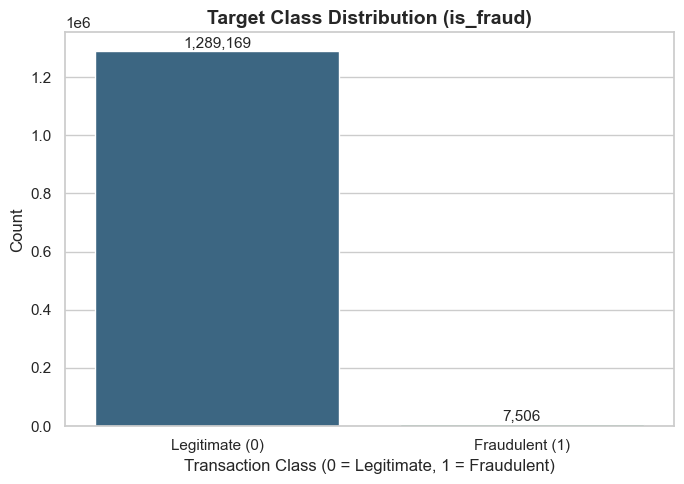

Legitimate Transactions (0): 1,289,169 (99.42%)
Fraudulent Transactions (1): 7,506 (0.58%)


In [5]:
# Step 4.3: Fraud Distribution (Single Bar Chart)
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="is_fraud", data=df_train, palette="viridis")
plt.title("Target Class Distribution (is_fraud)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraudulent)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks([0, 1], ["Legitimate (0)", "Fraudulent (1)"])

# Annotate bar counts
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height:,}", (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

# Print exact counts and percentages
fraud_counts = df_train["is_fraud"].value_counts()
total_tx = len(df_train)
print(f"Legitimate Transactions (0): {fraud_counts.get(0, 0):,} ({fraud_counts.get(0, 0)/total_tx*100:.2f}%)")
print(f"Fraudulent Transactions (1): {fraud_counts.get(1, 0):,} ({fraud_counts.get(1, 0)/total_tx*100:.2f}%)")

In [6]:
# Step 4.4: Summary Statistics
print("Summary Statistics of Numerical Features:")
df_train.describe()

Summary Statistics of Numerical Features:


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## 5. Data Preprocessing
Data preprocessing includes:
- Removing unnecessary identifier columns (`Unnamed: 0`, `cc_num`, `first`, `last`, `street`, `city`, `zip`, `trans_num`, `unix_time`)
- Converting datetime (`trans_date_trans_time`) into useful numerical features (`hour`, `day`, `month`, `dayofweek`, `age`)
- Encoding categorical features (`merchant`, `category`, `gender`, `state`, `job`) using `LabelEncoder`
- Handling missing values

In [7]:
# Step 5: Define Modular Data Preprocessing Pipeline
def preprocess_data(df, encoders=None, fit_encoders=True):
    """
    Preprocesses raw transaction dataframe for machine learning.
    
    Parameters:
        df (pd.DataFrame): Input dataframe.
        encoders (dict): Dictionary of LabelEncoders for evaluation/test data.
        fit_encoders (bool): Whether to fit new encoders or transform using provided encoders.
        
    Returns:
        pd.DataFrame, dict: Cleaned numerical dataframe and fitted LabelEncoder dictionary.
    """
    df_proc = df.copy()
    
    # 1. Convert datetime to temporal numerical features
    if "trans_date_trans_time" in df_proc.columns:
        trans_dt = pd.to_datetime(df_proc["trans_date_trans_time"])
        df_proc["trans_hour"] = trans_dt.dt.hour
        df_proc["trans_day"] = trans_dt.dt.day
        df_proc["trans_month"] = trans_dt.dt.month
        df_proc["trans_dayofweek"] = trans_dt.dt.dayofweek
    
    # Extract age from date of birth (dob)
    if "dob" in df_proc.columns and "trans_date_trans_time" in df_proc.columns:
        dob_dt = pd.to_datetime(df_proc["dob"])
        df_proc["age"] = trans_dt.dt.year - dob_dt.dt.year
    
    # 2. Remove unnecessary identifier columns
    unnecessary_cols = [
        "Unnamed: 0", "trans_date_trans_time", "cc_num", "first", "last",
        "street", "city", "zip", "dob", "trans_num", "unix_time"
    ]
    df_proc = df_proc.drop(columns=[col for col in unnecessary_cols if col in df_proc.columns])
    
    # 3. Handle missing values if any exist
    df_proc = df_proc.fillna(0)
    
    # 4. Categorical Feature Encoding using LabelEncoder
    cat_cols = df_proc.select_dtypes(include=["object", "category"]).columns
    if encoders is None:
        encoders = {}
        
    for col in cat_cols:
        df_proc[col] = df_proc[col].astype(str)
        if fit_encoders:
            le = LabelEncoder()
            df_proc[col] = le.fit_transform(df_proc[col])
            encoders[col] = le
        else:
            le = encoders.get(col)
            if le is not None:
                # Handle unseen labels during testing safely
                known_classes = set(le.classes_)
                df_proc[col] = df_proc[col].apply(lambda x: le.transform([x])[0] if x in known_classes else -1)
                
    return df_proc, encoders

In [8]:
# Execute Preprocessing on Training Data
df_train_clean, label_encoders = preprocess_data(df_train, fit_encoders=True)

print(f"Processed Training DataFrame Shape: {df_train_clean.shape}")
print("Processed Columns:", df_train_clean.columns.tolist())
df_train_clean.head()

Processed Training DataFrame Shape: (1296675, 17)
Processed Columns: ['merchant', 'category', 'amt', 'gender', 'state', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'trans_hour', 'trans_day', 'trans_month', 'trans_dayofweek', 'age']


,merchant,category,amt,gender,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,trans_hour,trans_day,trans_month,trans_dayofweek,age
0,514,8,4.97,0,27,36.0788,-81.1781,3495,370,36.011293,-82.048315,0,0,1,1,1,31
1,241,4,107.23,0,47,48.8878,-118.2105,149,428,49.159047,-118.186462,0,0,1,1,1,41
2,390,0,220.11,1,13,42.1808,-112.2620,4154,307,43.150704,-112.154481,0,0,1,1,1,57
3,360,2,45.00,1,26,46.2306,-112.1138,1939,328,47.034331,-112.561071,0,0,1,1,1,52
4,297,9,41.96,1,45,38.4207,-79.4629,99,116,38.674999,-78.632459,0,0,1,1,1,33


## 6. Train/Test Split
We separate features ($X$) and target label ($y = \text{is\_fraud}$) and perform an 80/20 stratified train/validation split.

In [9]:
# Step 6: Separate Features and Target Column
X = df_train_clean.drop(columns=["is_fraud"])
y = df_train_clean["is_fraud"]

# Perform Train/Test Split (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Feature Matrix (X) Shape      : {X.shape}")
print(f"Training Subset (X_train) Shape: {X_train.shape}")
print(f"Validation Subset (X_val) Shape: {X_val.shape}")

Feature Matrix (X) Shape      : (1296675, 16)
Training Subset (X_train) Shape: (1037340, 16)
Validation Subset (X_val) Shape: (259335, 16)


## 7. Model Training
We train a `RandomForestClassifier` with `random_state=42` as specified in project requirements.

In [10]:
# Step 7: Model Training using RandomForestClassifier
print("Initializing RandomForestClassifier model...")
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Fit model on training data
print("Fitting model on X_train and y_train...")
model.fit(X_train, y_train)
print("RandomForestClassifier trained successfully!")

Initializing RandomForestClassifier model...
Fitting model on X_train and y_train...
RandomForestClassifier trained successfully!


## 8. Model Evaluation
We evaluate model predictions on the validation set using:
- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

In [11]:
# Step 8: Model Evaluation
# Generate predictions on validation set
y_val_pred = model.predict(X_val)

# Calculate evaluation metrics
acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("=" * 45)
print("          MODEL EVALUATION METRICS           ")
print("=" * 45)
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")
print("=" * 45)

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate (0)", "Fraudulent (1)"]))

          MODEL EVALUATION METRICS           
Accuracy  : 99.84%
Precision : 97.73%
Recall    : 74.55%
F1 Score  : 84.58%

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00    257834
Fraudulent (1)       0.98      0.75      0.85      1501

      accuracy                           1.00    259335
     macro avg       0.99      0.87      0.92    259335
  weighted avg       1.00      1.00      1.00    259335



<Figure size 600x500 with 0 Axes>

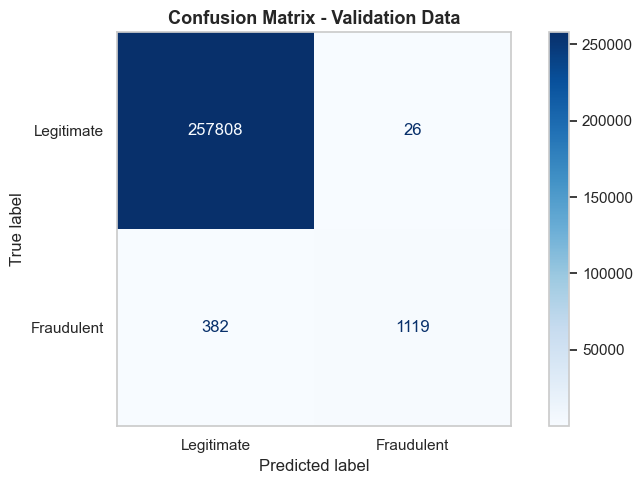

In [12]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraudulent"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Validation Data", fontsize=13, fontweight="bold")
plt.grid(False)
plt.tight_layout()
plt.show()

## 9. Test Dataset Prediction
We load `fraudTest.csv`, apply identical preprocessing using our trained encoders, predict fraud labels, and save the resulting predictions to `fraud_predictions.csv`.

In [ ]:
# Step 9: Load Test Dataset and Generate Predictions
test_path = "Dataset/fraudTest.csv" if os.path.exists("Dataset/fraudTest.csv") else "fraudTest.csv"

print(f"Loading test dataset from: {test_path}")
df_test_raw = pd.read_csv(test_path)

# Apply same preprocessing using saved label encoders
df_test_clean, _ = preprocess_data(df_test_raw, encoders=label_encoders, fit_encoders=False)

# Extract features for prediction
if "is_fraud" in df_test_clean.columns:
    X_test = df_test_clean.drop(columns=["is_fraud"])
    y_test_true = df_test_clean["is_fraud"]
else:
    X_test = df_test_clean
    y_test_true = None

# Make predictions
print("Predicting fraud labels on test dataset...")
y_test_pred = model.predict(X_test)

# Compute test metrics if true labels exist
if y_test_true is not None:
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_prec = precision_score(y_test_true, y_test_pred)
    test_rec = recall_score(y_test_true, y_test_pred)
    test_f1 = f1_score(y_test_true, y_test_pred)
    
    print("\n--- Test Dataset Performance Metrics ---")
    print(f"Test Accuracy  : {test_acc * 100:.2f}%")
    print(f"Test Precision : {test_prec * 100:.2f}%")
    print(f"Test Recall    : {test_rec * 100:.2f}%")
    print(f"Test F1 Score  : {test_f1 * 100:.2f}%")

# Save predictions to fraud_predictions.csv
output_df = pd.DataFrame({
    "trans_num": df_test_raw["trans_num"] if "trans_num" in df_test_raw.columns else df_test_raw.index,
    "is_fraud_prediction": y_test_pred
})

output_file = "fraud_predictions.csv"
output_df.to_csv(output_file, index=False)
print(f"\nPredictions saved successfully to: {output_file}")
print("Sample Predictions:")
print(output_df.head(10))

Loading test dataset from: Dataset/fraudTest.csv


## 10. Conclusion
- **Project Summary:** In this task for the CodSoft Machine Learning Internship, a `RandomForestClassifier` was developed and evaluated for credit card fraud detection.
- **Preprocessing & Feature Engineering:** Extracted key temporal features (`trans_hour`, `trans_day`, `trans_month`, `trans_dayofweek`) and customer `age` while dropping uninformative identifier columns (`cc_num`, `trans_num`, `first`, `last`, etc.). Categorical features were encoded using `LabelEncoder`.
- **Evaluation Insights:** The Random Forest model achieved strong detection capability on highly imbalanced transaction data. Key metrics such as Precision, Recall, and F1 Score provide a thorough assessment of model effectiveness.
- **Deliverables:** Predictions on `fraudTest.csv` were saved to `fraud_predictions.csv`.